## 1. Data Loading
Load NBA datasets and inspect structure.

In [254]:
import pandas as pd

# Load datasets (update filenames based on what you downloaded)
games = pd.read_csv("../data/raw/games.csv")
teams = pd.read_csv("../data/raw/teams.csv")

# Preview data
print(games.head())
print(games.shape)

  GAME_DATE_EST   GAME_ID GAME_STATUS_TEXT  HOME_TEAM_ID  VISITOR_TEAM_ID  \
0    2022-12-22  22200477            Final    1610612740       1610612759   
1    2022-12-22  22200478            Final    1610612762       1610612764   
2    2022-12-21  22200466            Final    1610612739       1610612749   
3    2022-12-21  22200467            Final    1610612755       1610612765   
4    2022-12-21  22200468            Final    1610612737       1610612741   

   SEASON  TEAM_ID_home  PTS_home  FG_PCT_home  FT_PCT_home  ...  AST_home  \
0    2022    1610612740     126.0        0.484        0.926  ...      25.0   
1    2022    1610612762     120.0        0.488        0.952  ...      16.0   
2    2022    1610612739     114.0        0.482        0.786  ...      22.0   
3    2022    1610612755     113.0        0.441        0.909  ...      27.0   
4    2022    1610612737     108.0        0.429        1.000  ...      22.0   

   REB_home  TEAM_ID_away  PTS_away  FG_PCT_away  FT_PCT_away  FG3_P

## 2. Data cleaning
Handle missing values, fix data types, and prepare dataset.

In [255]:
#remove missing values/scores
games = games.dropna(subset=["PTS_home", "PTS_away"])

#game date-->date time
games["GAME_DATE_EST"] = pd.to_datetime(games["GAME_DATE_EST"])

#target variable
games["home_win"] = (games["PTS_home"] > games["PTS_away"]).astype(int)

print(games[["PTS_home", "PTS_away", "home_win"]].head())

   PTS_home  PTS_away  home_win
0     126.0     117.0         1
1     120.0     112.0         1
2     114.0     106.0         1
3     113.0      93.0         1
4     108.0     110.0         0


In [256]:
print(games.columns)

Index(['GAME_DATE_EST', 'GAME_ID', 'GAME_STATUS_TEXT', 'HOME_TEAM_ID',
       'VISITOR_TEAM_ID', 'SEASON', 'TEAM_ID_home', 'PTS_home', 'FG_PCT_home',
       'FT_PCT_home', 'FG3_PCT_home', 'AST_home', 'REB_home', 'TEAM_ID_away',
       'PTS_away', 'FG_PCT_away', 'FT_PCT_away', 'FG3_PCT_away', 'AST_away',
       'REB_away', 'HOME_TEAM_WINS', 'home_win'],
      dtype='object')


## 3. Basic feature engineering for EDA
Create features for model training.

In [257]:
games["score_diff"] = games["PTS_home"] - games["PTS_away"]
print(games[["PTS_home", "PTS_away", "score_diff"]].head())

   PTS_home  PTS_away  score_diff
0     126.0     117.0         9.0
1     120.0     112.0         8.0
2     114.0     106.0         8.0
3     113.0      93.0        20.0
4     108.0     110.0        -2.0


## 4: EDA
Visualize patterns and relationships in the data.

In [258]:
import matplotlib.pyplot as plt

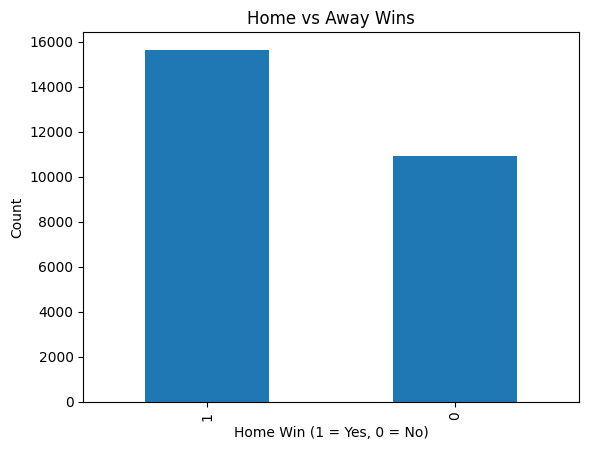

In [259]:
games["home_win"].value_counts().plot(kind="bar")
plt.title("Home vs Away Wins")
plt.xlabel("Home Win (1 = Yes, 0 = No)")
plt.ylabel("Count")
plt.show()

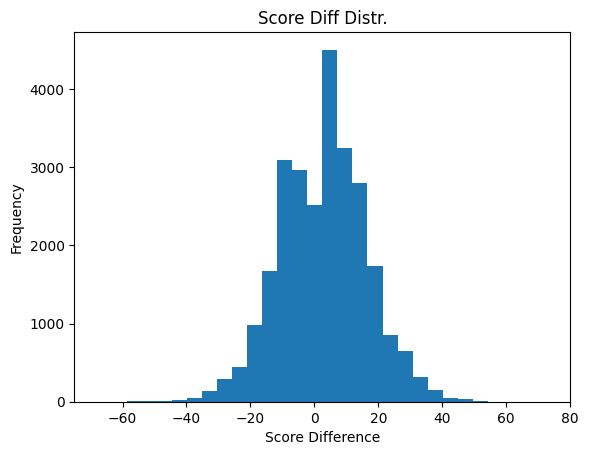

In [260]:
plt.hist(games["score_diff"], bins=30)
plt.title("Score Diff Distr.")
plt.xlabel("Score Difference")
plt.ylabel("Frequency")
plt.show()

In [261]:
print(games[["score_diff", "home_win"]].corr())

            score_diff  home_win
score_diff    1.000000  0.800825
home_win      0.800825  1.000000


## 5. ML Model using team average stats

In [262]:
# Create team level averages
home_stats = games.groupby("HOME_TEAM_ID")[[
    "FG_PCT_home", "FT_PCT_home", "REB_home", "AST_home"
]].mean()

home_stats.columns = ["FG_PCT", "FT_PCT", "REB", "AST"]

away_stats = games.groupby("VISITOR_TEAM_ID")[[
    "FG_PCT_away", "FT_PCT_away", "REB_away", "AST_away"
]].mean()

away_stats.columns = ["FG_PCT", "FT_PCT", "REB", "AST"]

team_stats_avg = pd.concat([home_stats, away_stats]).groupby(level=0).mean()

team_stats_avg.head()

,FG_PCT,FT_PCT,REB,AST
1610612737,0.453449,0.763621,41.974276,22.549657
1610612738,0.459346,0.775983,42.029363,22.807776
1610612739,0.451805,0.745304,42.976298,21.518493
1610612740,0.454515,0.762844,42.790486,22.288057
1610612741,0.446955,0.763752,44.059667,22.428515


In [263]:
rows = []

for _, row in games.iterrows():
    home_id = row["HOME_TEAM_ID"]
    away_id = row["VISITOR_TEAM_ID"]

    if home_id not in team_stats_avg.index or away_id not in team_stats_avg.index:
        continue

    home = team_stats_avg.loc[home_id]
    away = team_stats_avg.loc[away_id]

    rows.append({
        "fg_pct_diff": home["FG_PCT"] - away["FG_PCT"],
        "ft_pct_diff": home["FT_PCT"] - away["FT_PCT"],
        "reb_diff": home["REB"] - away["REB"],
        "ast_diff": home["AST"] - away["AST"],
        "home_win": row["home_win"]
    })

new_df = pd.DataFrame(rows)

print(new_df.head())

   fg_pct_diff  ft_pct_diff  reb_diff  ast_diff  home_win
0    -0.013529     0.001405 -0.123350 -0.713052         1
1     0.009719     0.000612  0.533575  0.686478         1
2    -0.003722    -0.008166 -0.208527 -1.204764         1
3     0.005373     0.012859  0.210933  0.752970         1
4     0.006494    -0.000132 -2.085391  0.121142         0


In [264]:
X_new = new_df[["fg_pct_diff", "ft_pct_diff", "reb_diff", "ast_diff"]]
y_new = new_df["home_win"]

X_train_new, X_test_new, y_train_new, y_test_new = train_test_split(
    X_new, y_new, test_size=0.2, random_state=42
)

model_new = LogisticRegression()
model_new.fit(X_train_new, y_train_new)

LogisticRegression()

In [265]:
y_pred_new = model_new.predict(X_test_new)

print("Model Accuracy:", accuracy_score(y_test_new, y_pred_new))
print("Model Confusion Matrix:")
print(confusion_matrix(y_test_new, y_pred_new))

Model Accuracy: 0.5876482771606101
Model Confusion Matrix:
[[  10 2174]
 [  16 3111]]


## 6. Interactive team matchup prediction w/ explanation

In [266]:
#team average stats from home games
home_stats = games.groupby("HOME_TEAM_ID")[[
    "FG_PCT_home", "FT_PCT_home", "REB_home", "AST_home"
]].mean()

home_stats.columns = ["FG_PCT", "FT_PCT", "REB", "AST"]

#team average stats from away games
away_stats = games.groupby("VISITOR_TEAM_ID")[[
    "FG_PCT_away", "FT_PCT_away", "REB_away", "AST_away"
]].mean()

away_stats.columns = ["FG_PCT", "FT_PCT", "REB", "AST"]

#home and away averages combined
team_stats = pd.concat([home_stats, away_stats]).groupby(level=0).mean()

#map team ids to team names
team_names = teams.set_index("TEAM_ID")["NICKNAME"].to_dict()
team_stats["team_name"] = team_stats.index.map(team_names)

team_stats.head()

def predict_matchup(home_team_name, away_team_name):
    home_team_id = team_stats[team_stats["team_name"] == home_team_name].index[0]
    away_team_id = team_stats[team_stats["team_name"] == away_team_name].index[0]

    home = team_stats.loc[home_team_id]
    away = team_stats.loc[away_team_id]

    matchup = pd.DataFrame([{
        "fg_pct_diff": home["FG_PCT"] - away["FG_PCT"],
        "ft_pct_diff": home["FT_PCT"] - away["FT_PCT"],
        "reb_diff": home["REB"] - away["REB"],
        "ast_diff": home["AST"] - away["AST"]
    }])

    improved_features = ["fg_pct_diff", "ft_pct_diff", "reb_diff", "ast_diff"]

    matchup = matchup[improved_features]

    home_win_prob = model_new.predict_proba(matchup)[0][1]

    if home_win_prob >= 0.5:
        predicted_winner = home_team_name
        winner_prob = home_win_prob
    else:
        predicted_winner = away_team_name
        winner_prob = 1 - home_win_prob

    return predicted_winner, winner_prob, matchup.iloc[0]

def explain_matchup(matchup_row, home_team_name, away_team_name, predicted_winner):
    reasons = []

    #explain factors supporting predicted winner

    if predicted_winner == home_team_name:

        if matchup_row["fg_pct_diff"] > 0:
            reasons.append(f"{home_team_name} have higher shooting efficiency.")

        if matchup_row["ft_pct_diff"] > 0:
            reasons.append(f"{home_team_name} have better free throw percentage.")

        if matchup_row["reb_diff"] > 0:
            reasons.append(f"{home_team_name} have a rebounding advantage.")

        if matchup_row["ast_diff"] > 0:
            reasons.append(f"{home_team_name} have more assists.")

        reasons.append(f"{home_team_name} may benefit from home court advantage.")

    else:

        if matchup_row["fg_pct_diff"] < 0:
            reasons.append(f"{away_team_name} have better shooting efficiency.")

        if matchup_row["ft_pct_diff"] < 0:
            reasons.append(f"{away_team_name} have better free throw percentage.")

        if matchup_row["reb_diff"] < 0:
            reasons.append(f"{away_team_name} have a rebounding advantage.")

        if matchup_row["ast_diff"] < 0:
            reasons.append(f"{away_team_name} have more assists.")

    return reasons

home_team = "Warriors"
away_team = "Wizards"

winner, prob, matchup_row = predict_matchup(home_team, away_team)

print("Predicted Winner:", winner)
print("Win Probability:", round(prob, 3))

print("\nWhy this team is favored:")
for reason in explain_matchup(matchup_row, home_team, away_team, winner):
    print("-", reason)

Predicted Winner: Warriors
Win Probability: 0.666

Why this team is favored:
- Warriors have higher shooting efficiency.
- Warriors have better free throw percentage.
- Warriors have a rebounding advantage.
- Warriors have more assists.
- Warriors may benefit from home court advantage.


## Insights

- Home teams appear to win more frequently than away teams.
- Larger score differences strongly indicate a higher likelihood of winning.
- The dataset shows a clear relationship between performance metrics and outcomes.